In [60]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import argparse
from pathlib import Path
import csv

In [61]:
image_path = Path('.').parent / '../maps/cdc_2024/cdc_2024_edited_with_line.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")


Processing ../maps/cdc_2024/cdc_2024_edited_with_line.pgm...


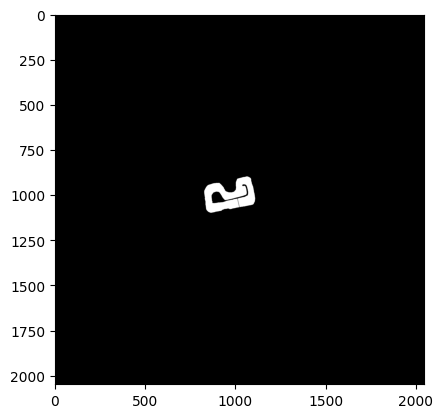

In [62]:
# Load the image
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Could not load image from {image_path}")
plt.imshow(img, cmap='gray')

In [63]:
print(f"Loaded image with shape: {img.shape}")

# Threshold the image to create a binary image
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Invert if the track is white (assuming track is darker than background)
if np.mean(binary) > 127: # type: ignore
    binary = 255 - binary

Loaded image with shape: (2048, 2048)


In [64]:
# Find contours - for boundary extraction
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

1

In [65]:
contours

(array([[[1058,  899]],
 
        [[1057,  900]],
 
        [[1055,  900]],
 
        [[1054,  901]],
 
        [[1051,  901]],
 
        [[1050,  902]],
 
        [[1043,  902]],
 
        [[1042,  903]],
 
        [[1038,  903]],
 
        [[1037,  904]],
 
        [[1036,  904]],
 
        [[1035,  905]],
 
        [[1032,  905]],
 
        [[1031,  906]],
 
        [[1028,  906]],
 
        [[1027,  907]],
 
        [[1024,  907]],
 
        [[1023,  908]],
 
        [[1020,  908]],
 
        [[1019,  909]],
 
        [[1017,  909]],
 
        [[1016,  910]],
 
        [[1012,  910]],
 
        [[1011,  911]],
 
        [[1010,  911]],
 
        [[1007,  914]],
 
        [[1007,  916]],
 
        [[1006,  917]],
 
        [[1006,  919]],
 
        [[1005,  920]],
 
        [[1005,  921]],
 
        [[1004,  922]],
 
        [[1004,  924]],
 
        [[1003,  925]],
 
        [[1003,  926]],
 
        [[1002,  927]],
 
        [[1002,  930]],
 
        [[1001,  931]],
 
        [[10

In [66]:

# Find the largest contour (assuming it's the track)
largest_contour = max(contours, key=cv2.contourArea)
print("Largest contour has shape:", largest_contour.shape)

Largest contour has shape: (355, 1, 2)


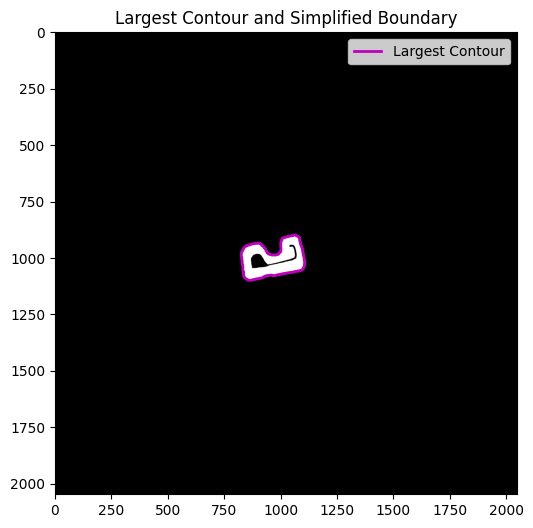

In [67]:
boundary_points = largest_contour

# Extract coordinates for plotting
largest_contour_coords =    [(point[0][0], point[0][1]) for point in largest_contour] # type: ignore
boundary_coords =           [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
largest_x = [p[0] for p in largest_contour_coords]
largest_y = [p[1] for p in largest_contour_coords]
plt.plot(largest_x, largest_y, 'm-', linewidth=2, label='Largest Contour')

plt.title('Largest Contour and Simplified Boundary')
plt.legend()
plt.show()


In [68]:

# Erode to create an artificial inner boundary
kernel = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=3)  # Adjust iterations as needed

# Extract all contours with hierarchy using RETR_CCOMP
contours, hierarchy = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Find the contour with the smallest area
inner_contour = None
if contours:
    inner_contour = min(contours, key=cv2.contourArea)
    # Optionally filter out tiny noise contours
    if cv2.contourArea(inner_contour) < 50:  # Adjust threshold as needed
        print("Smallest contour too small, might be noise.")
        inner_contour = None


In [69]:
inner_contour  = inner_contour.reshape(-1, 2) 
inner_contour_coords = inner_contour

In [70]:

# Simplify and get coordinates
# if inner_contour is not None:
#     print("Smallest contour shape before:", inner_contour.shape)
#     epsilon = 0.005 * cv2.arcLength(inner_contour, True)
#     inner_boundary = cv2.approxPolyDP(inner_contour, epsilon, True)
#     inner_coords = [(point[0][0], point[0][1]) for point in inner_boundary] # type: ignore
#     print("Smallest contour coods after:", inner_coords)
#     print(f"Smallest contour points: {len(inner_coords)}")
#     print(f"First few points: {inner_coords[:5]}")
# else:
#     inner_coords = []
#     print("No contours detected after erosion.")

# # Plot the smallest contour
# plt.figure(figsize=(8, 6))
# plt.imshow(binary, cmap='gray')
# if inner_coords:
#     inner_x = [p[0] for p in inner_coords]
#     inner_y = [p[1] for p in inner_coords]
#     plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')
#     plt.legend()
# else:
#     plt.title('No Inner Contour Found')
# plt.title('Smallest Inner Contour on Original Binary')
# plt.show()


In [ ]:
## Get the length of each

len(largest_contour_coords), len(inner_contour_coords)

(355, 271)

In [78]:
## Get outside point to inside point ratio
ratio  = len(largest_contour_coords) / len(inner_contour_coords)
ratio

1.3099630996309963

In [81]:
# Iterate over all points smallest contour and for each find the relavie on the largest contour with the ration

midpoints = []

for i, inner_track_point in enumerate(inner_contour_coords):
    largest_contour_coords_index = round(i * ratio)
    largest_contour_point = largest_contour_coords[largest_contour_coords_index]
    print(f"Point {i} in inner contour is at {inner_track_point} and point {largest_contour_coords_index} in largest contour is at {largest_contour_point}")

    # For each point find the point inbetween the two points
     # Compute the midpoint
    midpoint_x = (inner_track_point[0] + largest_contour_point[0]) / 2
    midpoint_y = (inner_track_point[1] + largest_contour_point[1]) / 2
    midpoint = (midpoint_x, midpoint_y)

    midpoints.append(midpoint)

    print(f"Midpoint between {inner_track_point} and {largest_contour_point} is {midpoint}")

Point 0 in inner contour is at [1037  940] and point 0 in largest contour is at (np.int32(1058), np.int32(899))
Midpoint between [1037  940] and (np.int32(1058), np.int32(899)) is (np.float64(1047.5), np.float64(919.5))
Point 1 in inner contour is at [1038  939] and point 1 in largest contour is at (np.int32(1057), np.int32(900))
Midpoint between [1038  939] and (np.int32(1057), np.int32(900)) is (np.float64(1047.5), np.float64(919.5))
Point 2 in inner contour is at [1052  939] and point 3 in largest contour is at (np.int32(1054), np.int32(901))
Midpoint between [1052  939] and (np.int32(1054), np.int32(901)) is (np.float64(1053.0), np.float64(920.0))
Point 3 in inner contour is at [1053  940] and point 4 in largest contour is at (np.int32(1051), np.int32(901))
Midpoint between [1053  940] and (np.int32(1051), np.int32(901)) is (np.float64(1052.0), np.float64(920.5))
Point 4 in inner contour is at [1056  940] and point 5 in largest contour is at (np.int32(1050), np.int32(902))
Midpoint

In [72]:
# Skeletonize to get centerline
# Distance transform + adaptive thresholding
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX)

# Improve skeleton by using an adaptive threshold based on max distance
max_dist = np.max(dist_transform[binary > 0])  # Max distance within track
factor = 0.5 ## Factor
thresh_value = max_dist * factor  # Threshold at half the max distance (adjustable)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin the skeleton with a single erosion step to refine it
kernel = np.ones((3, 3), np.uint8)
skeleton = cv2.erode(skeleton, kernel, iterations=1)

In [73]:
# # Find centerline points
# centerline_points = np.where(skeleton > 0)
# centerline_coords = [(x, y) for y, x in zip(centerline_points[0], centerline_points[1])]

# # Sort centerline points to follow the track
# if len(centerline_coords) > 1:
#     sorted_centerline = [centerline_coords[0]]
#     remaining = centerline_coords[1:]
    
#     while remaining:
#         print("Remaining points:", len(remaining))
#         last_point = sorted_centerline[-1]
#         distances = [np.sqrt((p[0] - last_point[0])**2 + (p[1] - last_point[1])**2) for p in remaining]
#         closest_idx = np.argmin(distances)
#         sorted_centerline.append(remaining[closest_idx])
#         remaining.pop(closest_idx)
        
#         # Break if remaining points are too far (gaps in track)
#         if distances[closest_idx] > 20 and len(sorted_centerline) > len(centerline_coords) // 2:
#             break
            
#     centerline_coords = sorted_centerline

In [ ]:
# Save to CSV if output path is provided
if output_path:
    with open(output_path / 'centerline.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(centerline_coords)
        
    with open(output_path / 'boundary.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(boundary_coords)

    plt.imsave(output_path / 'distance_transform.png', dist_norm, cmap='hot')
    plt.imsave(output_path / 'centerline.png', cv2.cvtColor(skeleton, cv2.COLOR_GRAY2RGB))
    plt.imsave(output_path / 'binary.png', binary, cmap='gray')
    plt.imsave(output_path / 'track.png', cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
    plt.imsave(output_path / 'track_with_coords.png', cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))    

# Visualize results

plt.figure(figsize=(12, 10))

# # Original image
# plt.subplot(2, 2, 1)
# plt.imshow(img, cmap='gray')
# plt.title('Original Track Image')

# # Binary image
# plt.subplot(2, 2, 2)
# plt.imshow(binary, cmap='gray')
# plt.title('Binary Track Image')

# # Distance transform
# plt.subplot(2, 2, 3)
# plt.imshow(dist_norm, cmap='hot')
# plt.title('Distance Transform')

# Result with coordinates
# plt.subplot(2, 2, 4)
plt.imshow(img, cmap='gray')
centerline_x = [p[0] for p in centerline_coords]
centerline_y = [p[1] for p in centerline_coords]
plt.plot(centerline_x, centerline_y, 'g-', linewidth=2, label='Centerline')
boundary_x = [p[0] for p in boundary_coords]
boundary_y = [p[1] for p in boundary_coords]

if inner_coords:
    inner_x = [p[0] for p in inner_coords]
    inner_y = [p[1] for p in inner_coords]
    plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')

plt.plot(boundary_x, boundary_y, 'b-', linewidth=2, label='Boundary')
plt.title('Extracted Track Coordinates')
plt.legend()

plt.tight_layout()
plt.show()
if output_path:
    plt.savefig(output_path / 'track_with_coords.png')

In [75]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)